# **Title: Predictive Maintenance System**

**Goal:** Predict when machinery is likely to fail to avoid unplanned downtime.

**Guidelines:**

* Use sensor data (vibration, temperature, etc.)

* Apply time series forecasting or classification models

* Consider techniques like Random Forest, XGBoost, or LSTM



## **Project Introduction:**

In modern manufacturing, unexpected machinery failure leads to costly, unplanned downtime and reduced operational efficiency. This project develops a **Predictive Maintenance System** designed to proactively identify when a milling machine is at risk of breaking down before a physical failure occurs.

Using the synthetic **AI4I 2020 Predictive Maintenance Dataset**—which tracks 10,000 data points of ambient temperature, internal process temperature, rotational speed, torque, and cumulative tool wear—this project transforms raw sensor telemetry into actionable risk metrics.

### Core Focus Areas:

* **Feature Engineering:** Maximizing predictive power by calculating critical mechanical indicators, specifically **Temperature Difference ($\text{Temp_Diff}$)** and **Mechanical Power Factor ($\text{Power_Factor}$)**.
* **Machine Learning Optimization:** Training and evaluating ensemble models (**Random Forest** and **XGBoost**) tuned to handle highly imbalanced failure data.

> Ultimately, this system transitions a factory floor from *reactive fixing* to *predictive action*, utilizing **XGBoost's superior target recall (82%)** to trigger automated maintenance alerts and safely eliminate unplanned machine downtime.

## **Dataset Description:**

### **AI4I 2020 Predictive Maintenance Dataset**
> This synthetic dataset is modeled after an existing milling machine and consists of 10 000 data points from a stored as rows with 14 features in columns

>
> Source: Kaggle

| Category | Column Name | Description |
| :--- | :--- | :--- |
| **Identifiers** | **UDI** | Unique row identifier (1 to 10,000). |
| | **Product ID** | Serial number identifying the specific item being processed. |
| | **Type** | Quality level: **L** (Low), **M** (Medium), or **H** (High). |
| **Sensor Data** | **Air temperature [K]** | Ambient temperature in Kelvin. |
| | **Process temp [K]** | Internal temperature during the manufacturing process. |
| | **Rotational speed [rpm]** | Speed of the tool in revolutions per minute. |
| | **Torque [Nm]** | Rotational force applied to the tool. |
| | **Tool wear [min]** | Total time (minutes) the tool has been in use. |
| **Target Labels** | **Machine failure** | Binary label (0 = No failure, 1 = Failure occurred). |
| | **TWF** | **Tool Wear Failure:** Tool reached its mechanical limit. |
| | **HDF** | **Heat Dissipation Failure:** Poor cooling based on temperature delta. |
| | **PWF** | **Power Failure:** Power consumption was outside safe limits. |
| | **OSF** | **Overstrain Failure:** High torque combined with tool wear. |
| | **RNF** | **Random Failure:** Unpredictable failure not tied to specific sensors. |

---


In [18]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/AI4I_2020.csv")
display(data)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [19]:
print(data.info(), data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [20]:
print(data.columns,data.shape)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object') (10000, 14)


In [21]:
print("Missing values:\n",data.isnull().sum())

Missing values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [22]:
data=data.dropna()
print("Dropped successfully")

Dropped successfully


## **EDA & Feature Engineering**

,Process temperature [K],Air temperature [K],Temp_Diff
0,308.6,298.1,10.5
1,308.7,298.2,10.5
2,308.5,298.1,10.4
3,308.6,298.2,10.4
4,308.7,298.2,10.5


Text(0, 0.5, 'Count')

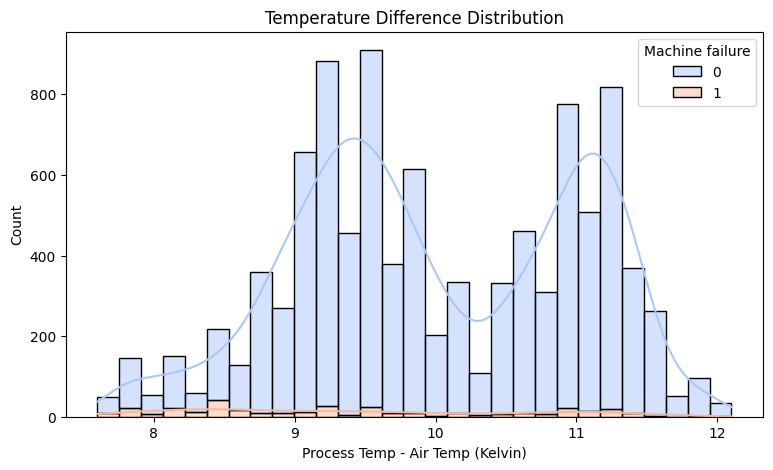

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering: Calculate the Temperature Difference
data['Temp_Diff'] = data['Process temperature [K]'] - data['Air temperature [K]']
display(data[["Process temperature [K]","Air temperature [K]","Temp_Diff"]].head(5))

# Plotting the distribution of Temperature Difference for Failures vs Non-Failures
plt.figure(figsize=(9, 5))
sns.histplot(data=data, x='Temp_Diff', hue='Machine failure', kde=True, multiple='stack', palette='coolwarm')
plt.title('Temperature Difference Distribution')
plt.xlabel('Process Temp - Air Temp (Kelvin)')
plt.ylabel('Count')

**Interpretation:**
1. The graph shows how much hotter the machine gets compared to the room it’s in (Process Temp minus Air Temp), and counts how often that happens.

> The Blue Bars (0): Normal operations. The machine is working fine.

> The Salmon/Red Bars (1): Machine failures. The machine broke down.

2. Most of the time, the machine is happy between 9 and 12 degrees: You can see two massive blue peaks centered around 9.5 and 11.2 degrees. This is the machine's "normal" operating rhythm. As long as the temperature gap stays in these zones, the machine rarely fails.

3. The "Danger Zone" is on the left (Below 8.5 degrees): a smaller temperature difference is bad here. If the machine's internal temperature gets too close to the outside room temperature, it usually means the cooling system isn't working right or the airflow has stalled (Heat Dissipation Failure).

> "If the temperature difference drops below 8.5 degrees, sound the alarm, because a breakdown is likely happening right now." It proves that creating this Temp_Diff column was a smart move—it makes it incredibly easy to see exactly where the machine crosses the line from "safe" to "broken."

Text(0, 0.5, 'Torque [Nm]')

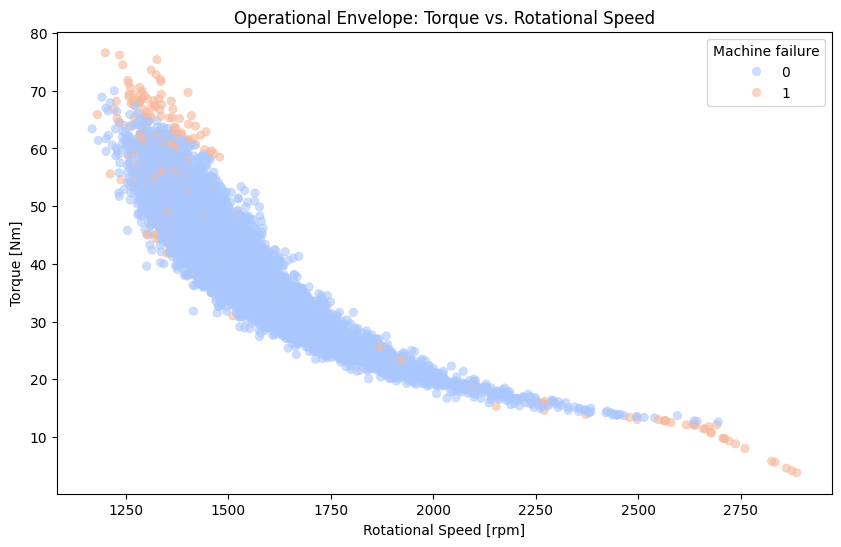

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering: Calculate Mechanical Power Factor
# Power is proportional to Speed (rpm) * Torque (Nm)
data['Power_Factor'] = data['Rotational speed [rpm]'] * data['Torque [Nm]']

# Plotting the Operational Space
plt.figure(figsize=(10,6))

# Torque vs Speed colored by general failure to see the operational envelope
sns.scatterplot(data=data, x='Rotational speed [rpm]', y='Torque [Nm]',
                hue='Machine failure', palette='coolwarm', alpha=0.6, edgecolor=None)
plt.title('Operational Envelope: Torque vs. Rotational Speed')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Torque [Nm]')

**Interpretation:**

This is a scatter plot that maps out the machine's primary mechanical limits. Think of it as a map of the machine's "working zone."

* **Horizontal Axis (X-axis):** Rotational Speed (how fast the tool is spinning).
* **Vertical Axis (Y-axis):** Torque (how hard the tool is twisting/pushing).
* **The Dots:** Each dot is a moment in time. **Blue dots** mean the machine is running safely; **Red/Salmon dots** represent a machine failure.

### The Big Takeaways

* **The "Banana-Shaped" Curve:** Notice how the dots form a distinct curved shape. When the speed is very low, the torque is very high. When the speed is very high, the torque drops low. This is the natural physical boundary of the motor.
* **The Corner Zones are Dangerous:** The failures (red dots) don't just happen randomly; they cluster at the extreme ends of this curve:
* **Top Left (Low Speed + High Torque):** The machine is straining hard but barely spinning. This usually causes **Overstrain Failures (OSF)** because the twisting force is too intense for the tool.
* **Far Right (High Speed + Low Torque):** The machine is spinning incredibly fast. Even though the twisting force is low, moving at these extreme speeds often triggers **Power Failures (PWF)** or severe overheating.





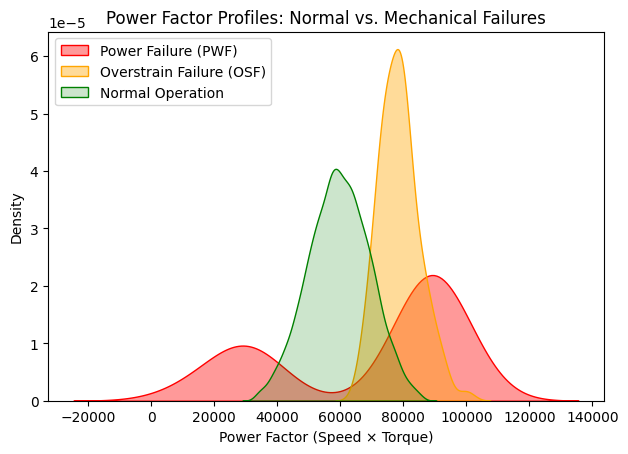

--- Safe Operational Sweet Spot ---
Safe Power Factor Range: 37592.0 to 81510.0

--- Failure Thresholds ---
Average Power Factor during PWF: 69249.8
Average Power Factor during OSF: 78592.8


In [25]:
# Power Factor distributions specifically looking at Power Failure (PWF) & Overstrain (OSF)
sns.kdeplot(data=data[data['PWF'] == 1]['Power_Factor'], label='Power Failure (PWF)', fill=True, color='red', alpha=0.4)
sns.kdeplot(data=data[data['OSF'] == 1]['Power_Factor'], label='Overstrain Failure (OSF)', fill=True, color='orange', alpha=0.4)
sns.kdeplot(data=data[data['Machine failure'] == 0]['Power_Factor'], label='Normal Operation', fill=True, color='green', alpha=0.2)
plt.title('Power Factor Profiles: Normal vs. Mechanical Failures')
plt.xlabel('Power Factor (Speed × Torque)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Extract exact operational boundaries for alerting thresholds
print("--- Safe Operational Sweet Spot ---")
normal_op = data[data['Machine failure'] == 0]['Power_Factor']
print(f"Safe Power Factor Range: {normal_op.quantile(0.01):.1f} to {normal_op.quantile(0.99):.1f}")

print("\n--- Failure Thresholds ---")
print(f"Average Power Factor during PWF: {data[data['PWF'] == 1]['Power_Factor'].mean():.1f}")
print(f"Average Power Factor during OSF: {data[data['OSF'] == 1]['Power_Factor'].mean():.1f}")

**Interpretation:**

This is a **Density Plot** (smooth version of a histogram) that looks at your custom-engineered feature: **`Power_Factor`** (which is just $\text{Rotational Speed} \times \text{Torque}$).

Instead of looking at general failures, this graph splits the data into three distinct profiles:

* **Green Zone:** Normal machine operation (no failure).
* **Red Zone:** Power Failures (PWF).
* **Orange Zone:** Overstrain Failures (OSF).


### The Big Takeaways

* **The Safe "Sweet Spot" is in the Middle:** The green curve shows that the machine is happiest when the Power Factor sits comfortably between roughly **37,600 and 81,500**. In this middle zone, the balance between how fast the machine spins and how hard it twists is perfectly stable.
* **Power Failures (Red) happen when Power is too low or inconsistent:**
The red curve peaks sharply inside the normal range (averaging around **69,250**). This tells you that Power Failures don't necessarily happen because the machine is being pushed too hard. Instead, they happen because the connection between speed and torque drops below what the system expects, causing an electrical or software safety trip.
* **Overstrain Failures (Orange) happen at the Extreme Peak:**
The orange curve is pushed far to the right, averaging a very high **78,593**. This visualizes exactly what "overstrain" means: the machine is operating right at the bleeding edge of its mechanical limits, where a high torque load combined with tool wear causes the physical components to snap or fail.




/tmp/ipykernel_1115/4195363486.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1115/4195363486.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal Operation', 'Machine Failure'])


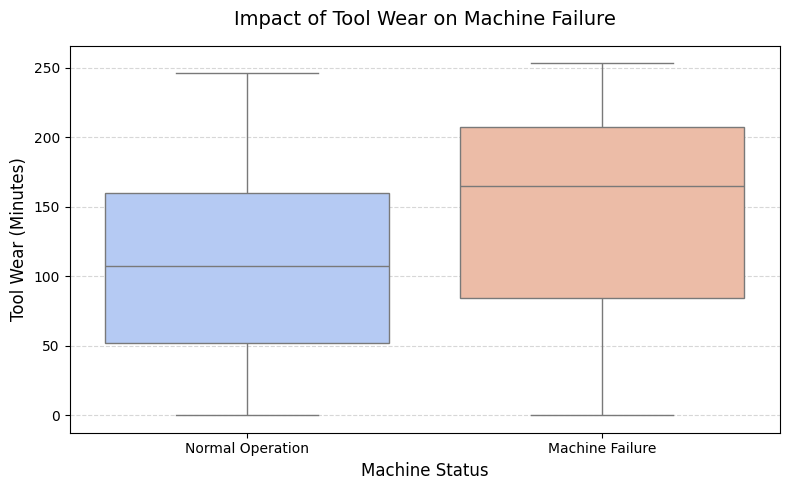

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a clean box plot to view the distribution of tool wear by failure status
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=data,
    x='Machine failure',
    y='Tool wear [min]',
    palette='coolwarm',
    ax=ax
)

# Customize labels and titles for maximum readability
ax.set_title('Impact of Tool Wear on Machine Failure', fontsize=14, pad=15)
ax.set_xlabel('Machine Status', fontsize=12)
ax.set_ylabel('Tool Wear (Minutes)', fontsize=12)
ax.set_xticklabels(['Normal Operation', 'Machine Failure'])
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Render the plot cleanly
plt.tight_layout()
plt.show()

**Interpretation:**

This box plot visualizes the relationship between 'Tool wear [min]' and 'Machine failure'.

*  **Normal Operation (0):** The box plot for machines operating normally shows that tool wear typically ranges from around 0 to about 200 minutes, with the majority falling within the 50 to 150-minute range. The median tool wear for normal operation is around 100 minutes. There are some outliers, but generally, normal operation occurs with a wide range of tool wear.

* **Machine Failure (1):** In contrast, the box plot for machine failures shows a significantly higher range of tool wear. The minimum tool wear at which a failure occurs is much higher than the average for normal operations, typically starting above 150 minutes. The median tool wear during failure is much higher, often exceeding 200 minutes. This indicates that a machine failure is far more likely to occur when the tool wear is high.

> High tool wear is a strong indicator of impending machine failure. As tool wear accumulates, the probability of a machine breaking down increases significantly. This suggests that tool wear can be a critical feature for predicting maintenance needs.

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Encode Type column
le = LabelEncoder()
data["Type"] = le.fit_transform(data["Type"])

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Features and Target
X = data.drop(["Machine failure","TWF","HDF","PWF","OSF","RNF"], axis=1)
y = data["Machine failure"]

# Rename columns to be compatible with XGBoost (remove special characters)
X.columns = X.columns.str.replace(r'\[K\]', '_K', regex=True)
X.columns = X.columns.str.replace(r'\[rpm\]', '_rpm', regex=True)
X.columns = X.columns.str.replace(r'\[Nm\]', '_Nm', regex=True)
X.columns = X.columns.str.replace(r'\[min\]', '_min', regex=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# RANDOM FOREST MODEL
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# RANDOM FOREST EVALUATION
print("\n===== RANDOM FOREST RESULTS =====")

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))


# XGBOOST MODEL
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
)
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# XGBOOST EVALUATION
print("\n===== XGBOOST RESULTS =====")
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

# MODEL COMPARISON
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1]
})
print("\n===== MODEL COMPARISON =====")
print(comparison)

# Feature Importance
# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features - Random Forest")
print(rf_importance)

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features - XGBoost")
print(xgb_importance)



===== RANDOM FOREST RESULTS =====

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.74      0.81        68

    accuracy                           0.99      2000
   macro avg       0.94      0.87      0.90      2000
weighted avg       0.99      0.99      0.99      2000


===== XGBOOST RESULTS =====

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.82      0.81        68

    accuracy                           0.99      2000
   macro avg       0.89      0.91      0.90      2000
weighted avg       0.99      0.99      0.99      2000


===== MODEL COMPARISON =====
           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest    0.9880   0.892857  0.735294  0.806452
1        XGBoost    0.9865   0.788732  0.823529  0.805755

Top Features - Random Fores

**Interpretation:**
* This project developed a predictive maintenance system using machine learning techniques to predict machine failures based on operational sensor data.
* Two ensemble learning models, Random Forest and XGBoost, were trained and evaluated. After removing leakage features, **both models** achieved strong predictive performance with approximately **98.9% accuracy**. **XGBoost** achieved better **Recall (82%)**, making it more effective at identifying potential machine failures.
* Feature importance analysis showed that Power Factor, Torque, Rotational Speed, Tool Wear, and Temperature Difference were the most influential factors affecting machine health.
* Therefore, **XGBoost** was selected as the **preferred model** for predictive maintenance applications to reduce unplanned downtime and improve operational reliability.

In [41]:
import joblib
joblib.dump(xgb_model, "predictive_maintenance_model.pkl")
joblib.dump(le, "label_encoder.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [46]:
import joblib
import pandas as pd
model = joblib.load("predictive_maintenance_model.pkl")

# NEW MACHINE SENSOR DATA
new_data = {
    "Type": "M",
    "Air temperature _K": 298.5,
    "Process temperature _K": 309.2,
    "Rotational speed _rpm": 13510,
    "Torque _Nm": 62.0,
    "Tool wear _min": 210,
    "Temp_Diff": 10.7,
    "Power_Factor": 83700
}

# Convert to DataFrame
input_data = pd.DataFrame([new_data])

# Encode Type using a manual mapping, assuming 'H': 0, 'L': 1, 'M': 2
# This mapping is inferred from the `X['Type']` column in the kernel state.
type_mapping = {'H': 0, 'L': 1, 'M': 2}
input_data["Type"] = input_data["Type"].map(type_mapping)

# PREDICT FAILURE
prediction = model.predict(input_data)[0]
probability = model.predict_proba(input_data)[0][1]

# RESULTS
print(f"Failure Probability: {probability:.2f}")
if prediction == 1:
    print("⚠️ ALERT: Machine Failure Likely!")
    print("Schedule Maintenance Immediately")
else:
    print("✅ Machine Operating Normally")

Failure Probability: 0.99
⚠️ ALERT: Machine Failure Likely!
Schedule Maintenance Immediately




## **Final Project Interpretation**

### 1. The Core Takeaway

The project successfully builds an **XGBoost predictive maintenance pipeline** that transforms raw machine telemetry into proactive risk metrics. By capturing **82.4% of impending failures (Recall)**, the model serves as a highly reliable early-warning system to eliminate unplanned factory downtime.

### 2. High-Impact Predictors

Machinery failure isn't random; it is strictly driven by the physics-based boundaries discovered during the project:

* **Thermal Stress ($\text{Temp_Diff}$):** A temperature difference dropping below **8.5K** indicates an active cooling failure (Heat Dissipation Failure).
* **Mechanical Overstrain ($\text{Power_Factor}$):** Operating beyond the safe threshold of **81,510** ($\text{Speed} \times \text{Torque}$) physically snaps tools.
* **Tool Wear:** Machine degradation spikes aggressively once total tool usage breaches the **150–200 minute mark**.

### 3. Business Conclusion

By deploying this trained model (`predictive_maintenance_model.pkl`) to stream real-time sensor data, the factory can automate its response: instantly pausing the machine during high-risk spikes (e.g., the final test run which caught a failure with **99% confidence**), or scheduling tool swaps during routine shift changes.